In [5]:
!pip install seaborn


In [6]:
# Install if needed:
# pip install scikit-learn pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split

import warnings
warnings.filterwarnings('ignore')

# Reproducibility — always set this
RANDOM_STATE = 42

In [50]:

# YOUR TASK:
# 1. Print shape, dtypes, and describe()
# 2. Check for null values
# 3. Print first 5 rows

# FILL IN HERE:
df=pd.read_csv("Mall_Customers.csv")

print(df.shape)
print("------------------------------")
print(df.dtypes)

print("------------------------------")

print(df.describe())
df.isnull().sum()




(200, 5)
------------------------------
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object
------------------------------
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [62]:
# 1. Select the two features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.shape
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print("Means:", X_scaled.mean(axis=0))
print("Stds:",  X_scaled.std(axis=0))

# We did not included gender and customerId beacuse gender is categorical data and it make no sense to apply scaling on categorical data as it is already scaled 0 or 1. Male/Female. And we did not include ID because it is just a number representing customers, it has nothing to do with orignal data. IT is just used to organize customers.  

Means: [-2.13162821e-16 -1.46549439e-16]
Stds: [1. 1.]


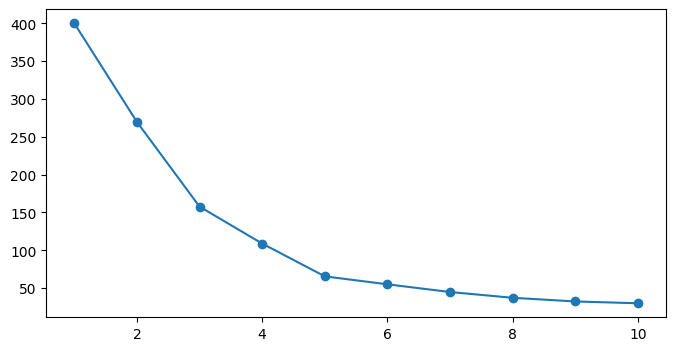

In [72]:
# ── CELL 3: Elbow Method ────────────────────────────────────────

inertia=[]
k_range=range(1,11)
for k in k_range:
    kmean=KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    kmean.fit(X_scaled)
    inertia.append(kmean.inertia_)

plt.figure(figsize=(8,4))
plt.plot(k_range,inertia,marker="o")




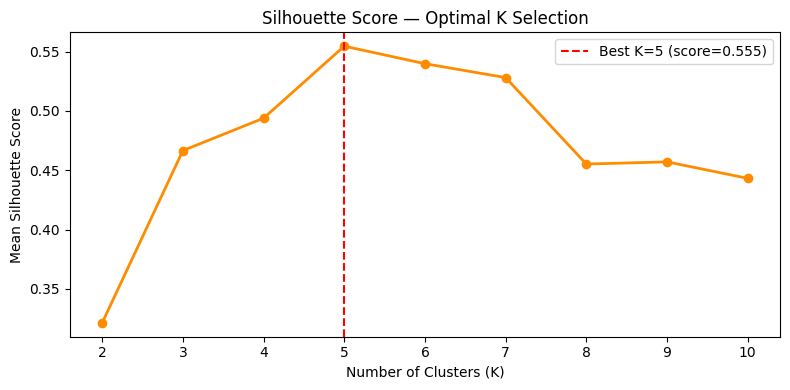

Optimal K by Silhouette: 5
Best Silhouette Score:   0.5547


In [100]:


sil_score=[]
ks_range=range(2,11)
for k in ks_range:
    kmean=KMeans(n_clusters=k,init="k-means++",n_init=10, random_state=RANDOM_STATE)
    labels=kmean.fit_predict(X_scaled)
    score=silhouette_score(X_scaled,labels) 
    sil_score.append(score)

    # ── PLOT ─────────────────────────────────────────────────────────
plt.figure(figsize=(8,4))
plt.plot(ks_range,sil_score,marker="o",linewidth=2, color="darkorange")
# Mark the best K
best_k = ks_range[np.argmax(sil_score)]
best_score = max(sil_score)

plt.axvline(x=best_k,
            color='red',
            linestyle='--',
            label=f'Best K={best_k} (score={best_score:.3f})')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Mean Silhouette Score')
plt.title('Silhouette Score — Optimal K Selection')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal K by Silhouette: {best_k}")
print(f"Best Silhouette Score:   {best_score:.4f}")




In [101]:

print("HELLO")

HELLO
